# Getting Stock Data with APIs
**Learn to fetch real stock prices and create simple visualizations**

## What You'll Build
A simple tool that gets stock price data from a free API and creates a basic chart using pandas plotting.

## Setup

In [1]:
# Install what we need
!pip install pandas requests matplotlib


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------------------------------------- - 8.1/8.3 MB 39.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 30.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 30.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 37.1 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ----------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\usman\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
# Import libraries
import pandas as pd
import requests
import matplotlib.pyplot as plt
from datetime import datetime

Matplotlib is building the font cache; this may take a moment.


## Step 1: Ask AI to Help Choose a Stock API

Let's start by asking Colab's AI about free stock APIs. But for this tutorial, we'll simulate the conversation.
```
Ask Colab AI: 'What are some free stock APIs I can use for learning? I want to get basic stock price data.'

AI Response would suggest options like:
- Alpha Vantage (free tier)
- Yahoo Finance (via yfinance)
- IEX Cloud (free tier)
- Finnhub (free tier)
```
For this tutorial, we'll use Alpha Vantage since it's beginner-friendly.

## Step 2: Ask AI to Help Build the API Call

Let's ask AI to help us structure the API request, you might get something like

In [6]:
api_key = "ZMCZ1LLQ7U96Z0MS"

def get_stock_data(symbol, api_key=api_key):
    """
    Get stock data from Alpha Vantage
    Using your personal API key
    """

    base_url = "https://www.alphavantage.co/query"

    params = {
        'function': 'TIME_SERIES_DAILY',
        'symbol': symbol,
        'apikey': api_key,
        'outputsize': 'compact'
    }

    try:
        response = requests.get(base_url, params=params)
        data = response.json()
        return data
    except Exception as e:
        return {"error": str(e)}

stock_data = get_stock_data("IBM")
print("Got data keys:", list(stock_data.keys()))
print(stock_data.get("Information", "No 'Information' field found."))

Got data keys: ['Meta Data', 'Time Series (Daily)']
No 'Information' field found.


Alpha Vantage keeps that key just for quick tests, and it only gives you a small sample (IBM daily data) or sometimes just the “Information” notice you’re seeing.

What to do

Sign up (free)
Go to https://www.alphavantage.co/support/#api-key
 and enter your email.
They immediately email you a personal API key—no credit card, no waiting.

Use your key in the code
Replace the default "demo" with the key you receive:
```python
stock_data = get_stock_data("IBM", api_key="YOUR_REAL_KEY_HERE")
print(stock_data.keys())
```

or edit the function call everywhere you need it.

Respect their limits
* The free tier allows 5 calls per minute and 500 calls per day.
* If you need more, they have paid plans.

Once you use your own key, the "Information" message will be replaced with real stock data in the usual "Meta Data" and "Time Series (Daily)" fields.

## Step 3: Ask AI to Help Parse the Data

Can you think of a prompt to the AI to help write the function?  The API returns JSON. Let's ask AI how to convert it to a pandas DataFrame:

In [7]:
def parse_stock_data(stock_data, symbol):
    """Convert API response to pandas DataFrame"""

    # Check if we got valid data
    if "Time Series (Daily)" not in stock_data:
        print("Error: No stock data found")
        print("Available keys:", list(stock_data.keys()))
        return None

    # Extract the time series data
    time_series = stock_data["Time Series (Daily)"]

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(time_series, orient='index')

    # Clean up column names
    df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

    # Convert to numeric
    df = df.astype(float)

    # Convert index to datetime
    df.index = pd.to_datetime(df.index)

    # Sort by date
    df = df.sort_index()

    # Add symbol column
    df['Symbol'] = symbol

    return df

# Parse the stock data
df = parse_stock_data(stock_data, "IBM")

if df is not None:
    print("Stock data sample:")
    print(df.head())
    print(f"\nData shape: {df.shape}")
else:
    print("Could not parse stock data")

Stock data sample:
               Open      High      Low   Close     Volume Symbol
2025-12-01  306.505  307.1200  302.800  305.67  3166555.0    IBM
2025-12-02  307.000  310.4675  301.570  301.78  4261100.0    IBM
2025-12-03  302.880  303.9700  298.905  302.62  3953390.0    IBM
2025-12-04  302.875  309.6100  302.540  307.99  2962463.0    IBM
2025-12-05  308.590  311.8300  307.180  307.94  2344667.0    IBM

Data shape: (100, 6)


## Step 4: Ask AI to Help Create a Simple Chart

Try this prompt (can you make it better?):

```
How do I create a simple line chart of stock prices using pandas?
```

You might get something like.  Now let's visualize the data:

In [11]:
import matplotlib.pyplot as plt

def plot_stock_price(df, symbol):
    if df is None or df.empty:
        print("No data to plot")
        return

    df['Close'].plot(title=f"{symbol} Stock Price", figsize=(10,5))
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.grid(True)
    plt.show()

    print(f"\n{symbol} Stats")
    print("Latest:", df['Close'].iloc[-1])
    print("High:", df['Close'].max())
    print("Low:", df['Close'].min())

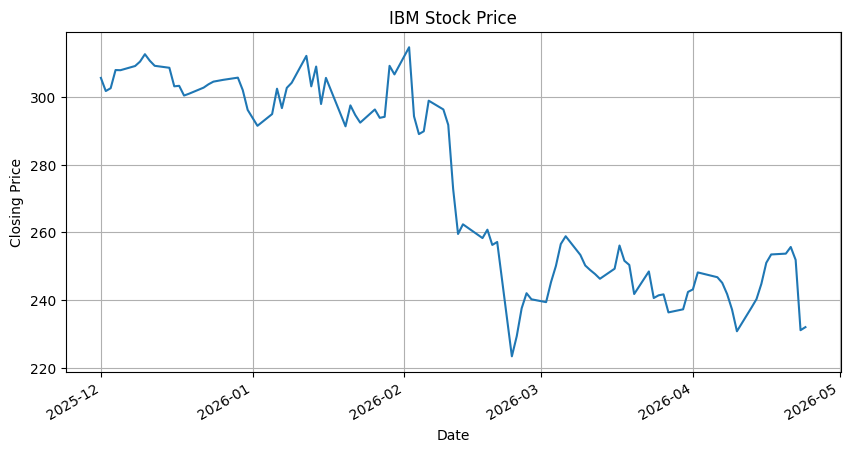


IBM Stats
Latest: 231.98
High: 314.73
Low: 223.35


In [12]:
plot_stock_price(df, "IBM")

## Step 5: Extension Ideas

Let's expand to:
* compare multiple stocks
* build a simple analysis function (see earlier notebook)
* Real-time price updates
* More technical indicators (RSI, MACD)
* Portfolio tracking
* Price alerts
* Integration with a web interface
* Fundamental data (P/E ratios, etc.)
* News sentiment analysis



## Your Turn: Add a Feature

Try adding one feature with AI help:

In [13]:
# Ask AI to help you add a specific feature
# Example: "Help me add a function to calculate the RSI (Relative Strength Index)"

def calculate_rsi(df, window=14):
    """Calculate RSI based on AI suggestions"""

    # This is where you'd implement based on AI help
    print("RSI calculation - ask AI for implementation details")
    return None

# Or ask for help with alerts
def price_alert_system(symbol, target_price, current_price):
    """Simple price alert system"""

    if current_price >= target_price:
        print(f"Alert! {symbol} has reached your target price.")
        print(f"Current price: {current_price}")
        print(f"Target price: {target_price}")
    else:
        print(f"{symbol} has not reached the target yet.")
        print(f"Current price: {current_price}")
        print(f"Target price: {target_price}")

In [14]:
current_price = df['Close'].iloc[-1]
price_alert_system("IBM", 250, current_price)

IBM has not reached the target yet.
Current price: 231.98
Target price: 250


## Key Takeaways

You've built a stock analysis tool that:
- Fetches real stock data from an API
- Converts JSON to pandas DataFrames
- Creates visualizations of stock prices
- Calculates basic financial metrics
- Compares multiple stocks

This demonstrates core skills for financial applications:
- API integration
- Data processing with pandas
- Basic financial analysis
- Data visualization

## Next Steps

- Get a real Alpha Vantage API key for more data
- Add more technical indicators
- Combine with the chatbot tutorial
- Build a Gradio interface for user interaction
- Integrate with portfolio tracking

The foundation you've built here can be extended into sophisticated financial analysis tools!